In [1]:
import sys
from pathlib import Path
import pandas as pd
import geopandas as gpd

parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir/'src'))
from map2grid import *

In [2]:
# '''
#     Extract power infrastructure data from OSM
#     Package: osm-flex (https://github.com/osm-flex/osm-flex)
#     `vietnam-latest.osm.pbf` was downloaded on 16-5-2024.
#     You can skip this step and read the geopakage data in "../data/osm" directly, see the cell below.
# '''
# gdf_power = load_osm_data('VNM')

# output_path="../data/osm"
# gens = import_osm_infras(gdf_power, 'power', ['plant', 'generator'], output_path)
# lines = import_osm_infras(gdf_power, 'power', ['line', 'minor_line', 'cable'], output_path)
# subs = import_osm_infras(gdf_power, 'power', ['substation'], output_path)
# trafos = import_osm_infras(gdf_power, 'power', ['transformer'], output_path)

In [3]:
'''
    Read GeoPackage data directly.
'''
lines = gpd.read_file("../data/osm/line.gpkg", driver='GPKG')
subs = gpd.read_file("../data/osm/substation.gpkg", driver='GPKG')

/scistor/ivm/mye500/miniconda3/envs/py311/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(
/scistor/ivm/mye500/miniconda3/envs/py311/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


In [4]:
nodes_gdf = extract_unique_endpoints(lines)

In [5]:
updated_gdf = add_endnodes_to_lines(lines, nodes_gdf)  # Add columns node1 and node2 to lines

In [6]:
subs_update = transform_osm_subs(subs, buffer_distance=200)

In [7]:
data_ways_update_osm_id, nodes_in_osm_subs = add_osm_ids_to_data(updated_gdf, subs_update)

In [8]:
data_ways_all_voltage = count_voltage_levels(data_ways_update_osm_id)

Start counting voltage levels...


Voltage levels count:
Voltage level 110 kV: 2214
Voltage level 220 kV: 989
Voltage level 500 kV: 3080
Count of rows with None voltage: 1972


In [9]:
print(len(data_ways_update_osm_id), len(data_ways_all_voltage))

8212 8255


In [10]:
data_ways_all_voltage[data_ways_all_voltage['vlevels']==2]

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,circuits,line,layer,geometry,node1,node2,geom_node1,geom_node2,Length,vlevels
21,306271499,line,220000,None,None,50,None,None,None,None,...,None,None,None,LINESTRING (695487.710406585 1192613.678089592...,40,1204890398,"(695487.710406585, 1192613.6780895926)","(692393.0159784743, 1197337.721887805)",7.681641,2
21,306271499,line,110000,None,None,50,None,None,None,None,...,None,None,None,LINESTRING (695487.710406585 1192613.678089592...,40,1204890398,"(695487.710406585, 1192613.6780895926)","(692393.0159784743, 1197337.721887805)",7.681641,2
28,306392927,line,220000,None,None,50,None,None,None,None,...,4,None,None,LINESTRING (693535.340113952 1198103.298671999...,51,52,"(693535.340113952, 1198103.2986719997)","(696953.7557265959, 1205905.58205772)",10.703178,2
28,306392927,line,110000,None,None,50,None,None,None,None,...,4,None,None,LINESTRING (693535.340113952 1198103.298671999...,51,52,"(693535.340113952, 1198103.2986719997)","(696953.7557265959, 1205905.58205772)",10.703178,2
166,400552554,line,220000,None,None,50,None,None,None,None,...,None,None,None,LINESTRING (696857.3042865028 1192133.74315324...,306259034,257,"(696975.5743583543, 1192256.6670652693)","(695515.2856387986, 1192283.8172333918)",1.667782,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6579,1274838472,line,110000,None,None,50,None,None,None,None,...,4,None,None,LINESTRING (697161.9337216325 1206199.88923984...,7468,7469,"(697161.9337216325, 1206199.8892398493)","(703973.1991397288, 1208574.563984857)",9.070519,2
6762,1288355262,line,110000,None,None,50,None,None,None,None,...,None,None,None,LINESTRING (818127.2230445582 1392013.50579706...,183249722,518,"(818112.4820340951, 1392115.2961825107)","(813329.4387594864, 1388776.0743535222)",7.197835,2
6762,1288355262,line,220000,None,None,50,None,None,None,None,...,None,None,None,LINESTRING (818127.2230445582 1392013.50579706...,183249722,518,"(818112.4820340951, 1392115.2961825107)","(813329.4387594864, 1388776.0743535222)",7.197835,2
6814,1289582759,line,220000,None,None,50,None,None,None,None,...,None,None,None,LINESTRING (695515.2856387986 1192283.81723339...,257,40,"(695515.2856387986, 1192283.8172333918)","(695487.710406585, 1192613.6780895926)",0.397214,2


In [11]:
buffer_distance = 200
output_path = '../outputs'

# Define boolean options
bool_options = {
    'plot_ways_original': True,  # Visualize all selected lines (original dataset)
    'histogram_length_busbars': True,  # Visualize the length of busbars
    'histogram_distances_between_endpoints': True,  # Visualize the distances between endpoints
    'histogram_stacked_endnodes': True,  # Visualize the number of stacked endpoints
    'plot_stacked_endnodes': True,  # Visualize all stacked endpoints on the map
}

In [12]:
# data_ways_length = calculate_length_route(data_ways_all_voltage)

Start deleting ways with type "busbar" or "bay"...
   ATTENTION! Way Element ID 1271355297 has type "busbar" or "bay", but is too long.
               Length: 32.37 km of max. 1.0 km
               This way won't be added to the "busbar" exception list.
   ATTENTION! Way Element ID 1293378775 has type "busbar" or "bay", but is too long.
               Length: 31.64 km of max. 1.0 km
               This way won't be added to the "busbar" exception list.


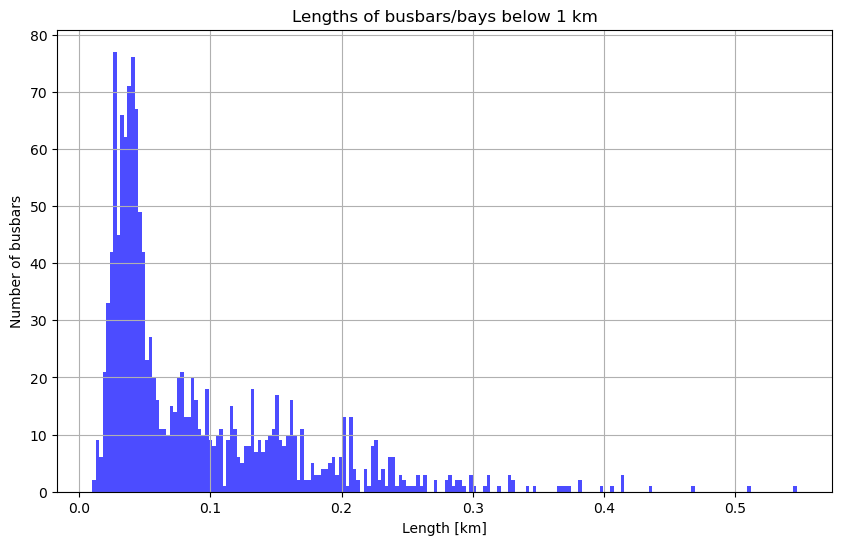

   ... there are 1391 busbars/bays in total
   ... 1389 busbars have been deleted
   ... finished! (0.390 seconds) 



In [13]:
data_ways_busbar, data_busbars = delete_busbars(data_ways_all_voltage, bool_options)

In [14]:
data_busbars.to_excel('../outputs/data_busbars.xlsx', index=False)

In [15]:
data_ways_dc, dc_candidates = count_possible_dc(data_ways_busbar, output_path)

Start detecting lines which could be DC lines...
   ... 727 ways could potentially be a DC line.
   ... Please refer to dc_candidates for further checks.
   ... finished! (0.157 seconds) 



In [16]:
data_ways_cables = count_cables(data_ways_dc)

Start counting cables per way...
Number of rows missing both cables and circuits: 1026
   ... finished!


In [17]:
data_ways_cables[['cables','circuits']]

,cables,circuits
0,6,2
1,3,1
2,6,2
3,3,1
4,6,2
...,...,...
6861,1,1
6862,1,1
6863,1,1
6864,3,1


   ... start visualizing all distances in a histogram ...


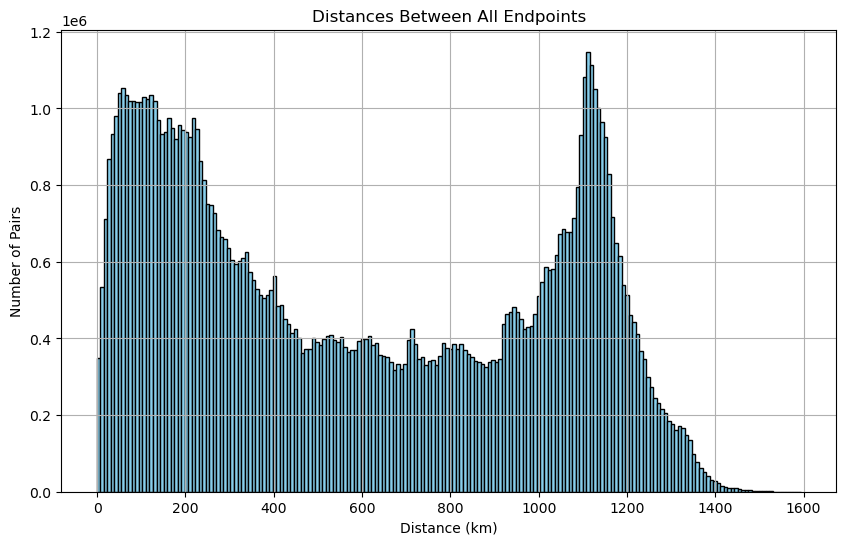

In [18]:
M = calc_distances_between_endpoints(data_ways_cables, bool_options)

Start finding all stacked endnodes...


... 9860 endnodes are stacked!
... finished! (0.574 seconds)

Reprojecting CRS from EPSG:32648 to EPSG:32648.


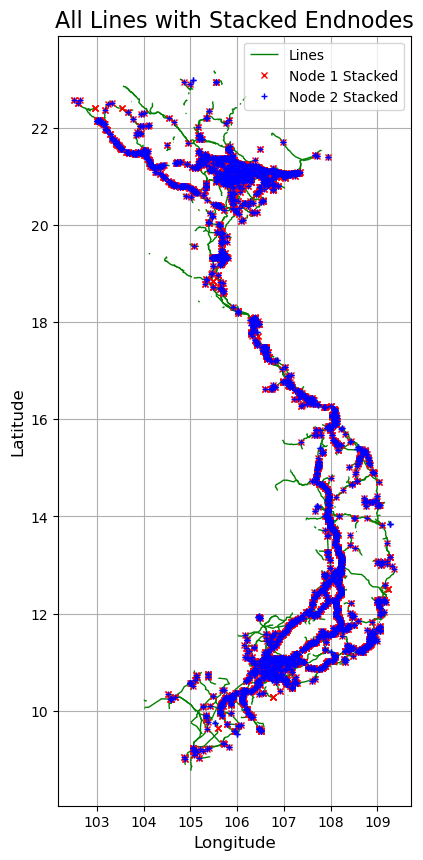

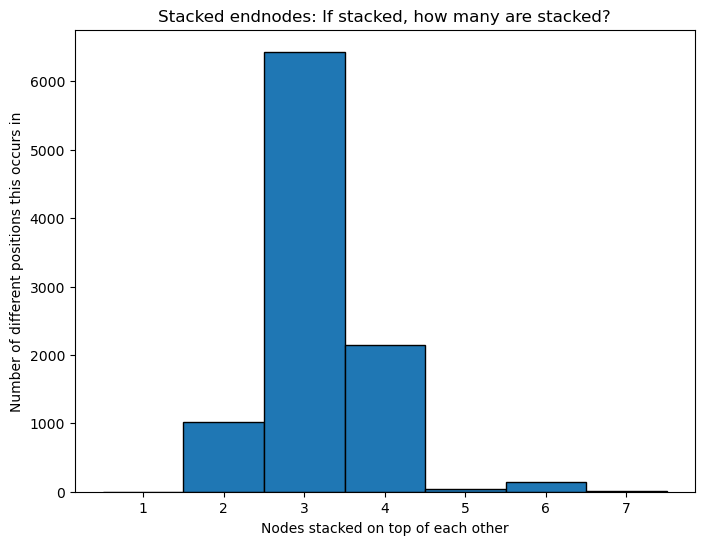

In [19]:
data_ways_stacked, nodes_stacked_pairs = calc_stacked_endnodes(data_ways_cables, M, bool_options)

In [20]:
nodes_stacked_grouped = group_nodes(nodes_stacked_pairs)

Start grouping all pairs from "pairs_input" (may take a few seconds)...


   ... 9860 nodes will be grouped together in 3231 groups,
       with an average of 3.05 nodes per group.
   ... finished! (1.706 seconds)



In [21]:
data_ways_group_stacked_nodes = group_stacked_endnodes(data_ways_cables, nodes_gdf, nodes_stacked_grouped)

Completed updating coordinates for stacked groups.


In [22]:
data_ways_final_coords = add_final_coordinates(data_ways_group_stacked_nodes)

Start adding final coordinates...
... finished!


In [23]:
data_ways_delete, data_singular_ways = delete_singular_ways(data_ways_final_coords, 'ID_node1_final', 'ID_node2_final')

Start deleting ways which have the same endpoints after grouping...
   ... 1073 ways were deleted!
   ... finished! (0.005 seconds)


In [24]:
data_singular_ways.to_excel('../outputs/data_singular_ways.xlsx', index=False)

In [25]:
# plot_ways_original(data_ways_delete, data_busbars, data_singular_ways, bool_options)

Start plotting original ways... (takes a few seconds)


/net/sys/pscst201/BETA-IVM-HPC@ada-nodes/mye500/projects/PowerGridCascade/src/map2grid.py:1363: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'r--', color="red", linewidth=1, label="Busbars")
/net/sys/pscst201/BETA-IVM-HPC@ada-nodes/mye500/projects/PowerGridCascade/src/map2grid.py:1366: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'r--', color="red", linewidth=1)
/net/sys/pscst201/BETA-IVM-HPC@ada-nodes/mye500/projects/PowerGridCascade/src/map2grid.py:1375: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'k--', color="purple", linewidth=1, label="Deleted lines")
/net/sys/pscst201/BETA-IVM-HPC@ada-n

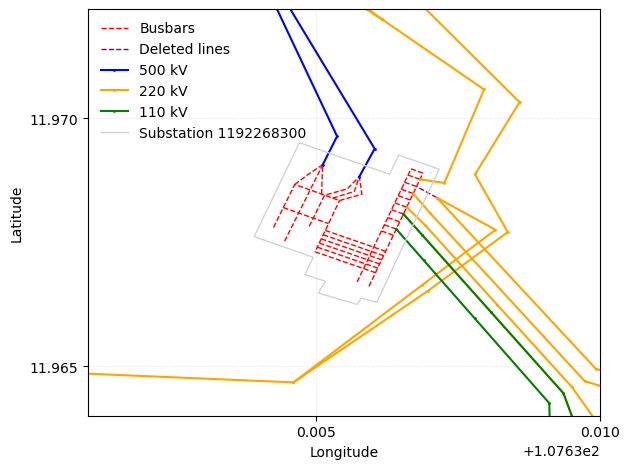

In [26]:
plot_ways_original(data_ways_delete, data_busbars, data_singular_ways, bool_options, xlim=(107.631, 107.640), ylim=(11.964, 11.9722), subs=subs)

In [30]:
data_ways_clone = add_lineID_clone_ways(data_ways_delete)

Start adding "LineID" and cloning ways...
   ... 406 ways doubled, 4 tripled, 17 quadrupled.
   ... finished! (4.414 seconds) 



In [31]:
# table_lines = fill_line_voltage(data_ways_clone)

In [32]:
table_lines = fill_line_info(data_ways_clone)

Number of removed lines without voltage levels after process:  518


c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set 

In [33]:
print("Number of lines before/after removing those without voltage level: ",
      len(data_ways_clone), len(table_lines))

Number of lines before/after removing those without voltage level:  7963 7445


In [34]:
table_lines.head()

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,ID_node1_final,lon1_final,lat1_final,ID_node2_final,lon2_final,lat2_final,LineID,std_type,max_i_ka,apprent_power
0,153608701,line,110.0,None,None,50,None,None,None,None,...,153608703.0,610714.852695,2.315181e+06,1.000000e+00,609979.512105,2.317122e+06,LINEVN0001a,490-AL1/64-ST1A 110.0,0.96,182.904565
1,153608701,line,110.0,None,None,50,None,None,None,None,...,153608703.0,610714.852695,2.315181e+06,1.000000e+00,609979.512105,2.317122e+06,LINEVN0001b,490-AL1/64-ST1A 110.0,0.96,182.904565
2,176708144,line,110.0,None,None,50,None,None,None,None,...,2.0,672622.408581,1.278800e+06,1.197858e+09,651889.179899,1.285444e+06,LINEVN0002,490-AL1/64-ST1A 110.0,0.96,182.904565
3,241194661,line,220.0,None,None,50,None,None,None,None,...,4.0,682154.017051,2.315888e+06,2.410654e+08,684741.069151,2.304331e+06,LINEVN0003a,490-AL1/64-ST1A 220.0,0.96,365.809131
4,241194661,line,220.0,None,None,50,None,None,None,None,...,4.0,682154.017051,2.315888e+06,2.410654e+08,684741.069151,2.304331e+06,LINEVN0003b,490-AL1/64-ST1A 220.0,0.96,365.809131


In [36]:
# For test
nodes_gdf = fill_node_info(table_lines)

\\pscst001.scistor.vu.nl\BETA-IVM-BAZIS\mye500\projects\Map2Grid\src\map2grid.py:1252: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NODEVN0001' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  nodes.loc[group.index, 'NodeID'] = base_id


In [ ]:
# nodes_original = pd.concat([
#     data_ways_clone[['ID_node1_final', 'voltage', 'lon1_final', 'lat1_final']].rename(
#         columns={'ID_node1_final': 'NodeID', 'lon1_final': 'lon', 'lat1_final': 'lat'}
#     ),
#     data_ways_clone[['ID_node2_final', 'voltage', 'lon2_final', 'lat2_final']].rename(
#         columns={'ID_node2_final': 'NodeID', 'lon2_final': 'lon', 'lat2_final': 'lat'}
#     )
# ]).drop_duplicates(subset=['NodeID', 'voltage']).reset_index(drop=True)

# print("Number of nodes before/after removing those without voltage level: ",
#       len(nodes_original), len(nodes_gdf))

Number of nodes before/after removing those without voltage level:  5130 4331


In [37]:
nodes_gdf.head()

,NodeID,voltage,lon,lat,geometry,OriginalID
0,NODEVN3270a,110.0,610714.852695,2.315181e+06,POINT (610714.853 2315180.7),153608703.0
1,NODEVN0002,110.0,672622.408581,1.278800e+06,POINT (672622.409 1278800.027),2.0
2,NODEVN0003a,220.0,682154.017051,2.315888e+06,POINT (682154.017 2315887.79),4.0
3,NODEVN3273a,110.0,684889.726446,2.304274e+06,POINT (684889.726 2304273.827),241065371.0
4,NODEVN3273b,220.0,684710.914392,2.304283e+06,POINT (684710.914 2304282.784),241065371.0


In [38]:
table_lines.head()

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,ID_node1_final,lon1_final,lat1_final,ID_node2_final,lon2_final,lat2_final,LineID,std_type,max_i_ka,apprent_power
0,153608701,line,110.0,None,None,50,None,None,None,None,...,153608703.0,610714.852695,2.315181e+06,1.000000e+00,609979.512105,2.317122e+06,LINEVN0001a,490-AL1/64-ST1A 110.0,0.96,182.904565
1,153608701,line,110.0,None,None,50,None,None,None,None,...,153608703.0,610714.852695,2.315181e+06,1.000000e+00,609979.512105,2.317122e+06,LINEVN0001b,490-AL1/64-ST1A 110.0,0.96,182.904565
2,176708144,line,110.0,None,None,50,None,None,None,None,...,2.0,672622.408581,1.278800e+06,1.197858e+09,651889.179899,1.285444e+06,LINEVN0002,490-AL1/64-ST1A 110.0,0.96,182.904565
3,241194661,line,220.0,None,None,50,None,None,None,None,...,4.0,682154.017051,2.315888e+06,2.410654e+08,684741.069151,2.304331e+06,LINEVN0003a,490-AL1/64-ST1A 220.0,0.96,365.809131
4,241194661,line,220.0,None,None,50,None,None,None,None,...,4.0,682154.017051,2.315888e+06,2.410654e+08,684741.069151,2.304331e+06,LINEVN0003b,490-AL1/64-ST1A 220.0,0.96,365.809131


In [42]:
export_data(table_lines, nodes_gdf, output_dir=output_path)

... finished!


#### Post-process

In [43]:
lines_gdf = gpd.read_file('../outputs/table_lines_200m.gpkg')
nodes_gdf = gpd.read_file('../outputs/table_nodes_200m.gpkg')

In [44]:
lines_gdf[['fromNode', 'toNode']] = lines_gdf[['fromNode', 'toNode']].astype(float).astype(int)
lines_gdf['voltage'] = lines_gdf['voltage'].astype(float)
lines_gdf['apprent_power'] = lines_gdf['apprent_power'].astype(float)

nodes_gdf['voltage'] = nodes_gdf['voltage'].astype(float)

# Replace fromNode
from_merge = lines_gdf.merge(nodes_gdf, left_on=['fromNode', 'voltage'], 
                         right_on=['OriginalID', 'voltage'], how='left', suffixes=('', '_nodes'))
lines_gdf['fromNode'] = from_merge['NodeID']

# Replace toNode
to_merge = lines_gdf.merge(nodes_gdf, left_on=['toNode', 'voltage'], 
                       right_on=['OriginalID', 'voltage'], how='left', suffixes=('', '_nodes'))
lines_gdf['toNode'] = to_merge['NodeID']

C:\Users\mye500\AppData\Local\Temp\ipykernel_23720\3855913928.py:8: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  from_merge = lines_gdf.merge(nodes_gdf, left_on=['fromNode', 'voltage'],
C:\Users\mye500\AppData\Local\Temp\ipykernel_23720\3855913928.py:13: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  to_merge = lines_gdf.merge(nodes_gdf, left_on=['toNode', 'voltage'],


In [45]:
# Calculate nominal apparent power of nodes (sn_mva)

# 1. 将两端点分别展开为单独的行
lines_exploded = pd.concat([
    lines_gdf[["fromNode", "apprent_power"]].rename(columns={"fromNode": "NodeID"}),
    lines_gdf[["toNode", "apprent_power"]].rename(columns={"toNode": "NodeID"})
])

# 2. 按 NodeID 统计连接数量和apprent_power总和
agg_df = lines_exploded.groupby("NodeID").agg(
    line_counts=("NodeID", "count"),
    sn_mva=("apprent_power", "sum")
).reset_index()

# 3. 合并回 nodes_gdf
nodes_gdf = nodes_gdf.merge(agg_df, on="NodeID", how="left")

# 4. 对于没有连接的节点填充 0
nodes_gdf[["line_counts", "sn_mva"]] = nodes_gdf[["line_counts", "sn_mva"]].fillna(0)

nodes_gdf.head()

,NodeID,voltage,lon,lat,OriginalID,geometry,line_counts,sn_mva
0,NODEVN3270a,110.0,610714.852695,2.315181e+06,153608703.0,POINT (610714.853 2315180.7),4.0,731.618261
1,NODEVN0002,110.0,672622.408581,1.278800e+06,2.0,POINT (672622.409 1278800.027),1.0,182.904565
2,NODEVN0003a,220.0,682154.017051,2.315888e+06,4.0,POINT (682154.017 2315887.79),6.0,2194.854783
3,NODEVN3273a,110.0,684889.726446,2.304274e+06,241065371.0,POINT (684889.726 2304273.827),3.0,548.713696
4,NODEVN3273b,220.0,684710.914392,2.304283e+06,241065371.0,POINT (684710.914 2304282.784),4.0,1463.236522


In [46]:
nodes_gdf.to_file(f"../outputs/table_nodes_200m_update.gpkg", layer='nodes', driver='GPKG')
lines_gdf.to_file(f"../outputs/table_lines_200m_update.gpkg", layer='lines', driver='GPKG')

with pd.ExcelWriter("../outputs/network_data.xlsx") as writer:
    nodes_gdf.to_excel(writer, sheet_name="nodes", index=False)
    lines_gdf.to_excel(writer, sheet_name="lines", index=False)

### Create transformers

In [47]:
type(lines_gdf.iloc[0]["apprent_power"])

numpy.float64

In [48]:
# Initialize a list to store transformer information
transformer_data = []

# Group by OriginalID to find buses with different voltages
grouped = nodes_gdf.groupby('OriginalID')

for original_id, group in grouped:
    voltage_counts = group['voltage'].value_counts()
    if len(voltage_counts) == 1:
        # Only one voltage -> skip
        continue

    sorted_group = group.sort_values(by='voltage', ascending=False).reset_index(drop=True)
    
    if len(voltage_counts) == 2:
        hv_row = sorted_group.iloc[0]
        lv_row = sorted_group.iloc[1]

        hv_v = hv_row['voltage']
        lv_v = lv_row['voltage']

        if hv_v == 500.0 and lv_v == 220.0:
            # std_type = "trafo_500_220"
            transformer_data.append({
                'name': f"{original_id}_hl2",
                'hv_bus': hv_row['NodeID'],
                'lv_bus': lv_row['NodeID'],
                'sn_mva': max(hv_row['sn_mva'], lv_row['sn_mva']) / hv_row['line_counts'],
                "vn_hv_kv": 500.0,
                "vn_lv_kv": 220.0,
                "vk_percent": 14.0,
                "vkr_percent": 0.5,
                "pfe_kw": 40.0,
                "i0_percent": 0.10,
                'geometry': hv_row['geometry'],
                # 'std_type': std_type
            })
        elif hv_v == 500.0 and lv_v == 110.0:
            # std_type = "trafo_500_110"
            transformer_data.append({
                'name': f"{original_id}_hl2",
                'hv_bus': hv_row['NodeID'],
                'lv_bus': lv_row['NodeID'],
                'sn_mva': max(hv_row['sn_mva'], lv_row['sn_mva']) / hv_row['line_counts'],
                "vn_hv_kv": 500.0,
                "vn_lv_kv": 110.0,
                "vk_percent": 14.5,
                "vkr_percent": 0.6,
                "pfe_kw": 40.0,
                "i0_percent": 0.12,
                'geometry': hv_row['geometry'],
                # 'std_type': std_type
            })
        elif hv_v == 220.0 and lv_v == 110.0:
            # std_type = "trafo_220_110"
            transformer_data.append({
                'name': f"{original_id}_hl2",
                'hv_bus': hv_row['NodeID'],
                'lv_bus': lv_row['NodeID'],
                'sn_mva': max(hv_row['sn_mva'], lv_row['sn_mva']) / hv_row['line_counts'],
                "vn_hv_kv": 220.0,
                "vn_lv_kv": 110.0,
                "vk_percent": 12.0,
                "vkr_percent": 0.7,
                "pfe_kw": 30.0,
                "i0_percent": 0.15,
                'geometry': hv_row['geometry'],
                # 'std_type': std_type
            })
        else:
            print(f"Warning: Unhandled voltage pair ({hv_v}/{lv_v}) at OriginalID {original_id}")
            continue

# ----------------------------------

    elif len(voltage_counts) == 3:
        hv_row = sorted_group.iloc[0]  # 500
        mv_row = sorted_group.iloc[1]  # 220
        lv_row = sorted_group.iloc[2]  # 110

        # create 3 two-winding transformers for hv-mv, hv-lv, mv-lv
        transformer_data.append({
            'name': f"{original_id}_hl3",
            'hv_bus': hv_row['NodeID'],
            'lv_bus': lv_row['NodeID'],
            'sn_mva': max(hv_row['sn_mva'], lv_row['sn_mva']) / hv_row['line_counts'],
            "vn_hv_kv": 500.0,
            "vn_lv_kv": 110.0,
            "vk_percent": 14.5,
            "vkr_percent": 0.6,
            "pfe_kw": 40.0,
            "i0_percent": 0.12,
            'geometry': hv_row['geometry'],            
            'geometry': sorted_group.iloc[0]['geometry'],
            # 'std_type': "trafo_500_110"
        })

        transformer_data.append({
            'name': f"{original_id}_hm3",
            'hv_bus': hv_row['NodeID'],
            'lv_bus': mv_row['NodeID'],
            'sn_mva': max(hv_row['sn_mva'], mv_row['sn_mva']) / hv_row['line_counts'],
            "vn_hv_kv": 500.0,
            "vn_lv_kv": 220.0,
            "vk_percent": 14.0,
            "vkr_percent": 0.5,
            "pfe_kw": 40.0,
            "i0_percent": 0.10,
            'geometry': sorted_group.iloc[0]['geometry'],
            # 'std_type': "trafo_500_220"
        })

        transformer_data.append({
            'name': f"{original_id}_ml3",
            'hv_bus': mv_row['NodeID'],
            'lv_bus': lv_row['NodeID'],
            'sn_mva': max(mv_row['sn_mva'], lv_row['sn_mva']) / hv_row['line_counts'],
            "vn_hv_kv": 220.0,
            "vn_lv_kv": 110.0,
            "vk_percent": 12.0,
            "vkr_percent": 0.7,
            "pfe_kw": 30.0,
            "i0_percent": 0.15,
            'geometry': sorted_group.iloc[0]['geometry'],
            # 'std_type': "trafo_220_110"
        })

transformer_data = pd.DataFrame(transformer_data)
transformer_gdf = gpd.GeoDataFrame(transformer_data, geometry=transformer_data['geometry'], crs='EPSG:32648')
transformer_gdf = transformer_gdf[['name', 'hv_bus', 'lv_bus', 'sn_mva', 'vn_hv_kv', 'vn_lv_kv',
                                 'vk_percent', 'vkr_percent', 'pfe_kw', 'i0_percent', 'geometry']]

In [49]:
transformer_gdf.head()

,name,hv_bus,lv_bus,sn_mva,vn_hv_kv,vn_lv_kv,vk_percent,vkr_percent,pfe_kw,i0_percent,geometry
0,4.0_hl2,NODEVN0003a,NODEVN0003b,365.809131,220.0,110.0,12.0,0.7,30.0,0.15,POINT (682154.017 2315887.79)
1,19.0_hl2,NODEVN0011b,NODEVN0011a,365.809131,220.0,110.0,12.0,0.7,30.0,0.15,POINT (589125.923 2317587.263)
2,40.0_hl2,NODEVN0019a,NODEVN0019b,365.809131,220.0,110.0,12.0,0.7,30.0,0.15,POINT (695487.71 1192613.678)
3,51.0_hl2,NODEVN0026a,NODEVN0026b,365.809131,220.0,110.0,12.0,0.7,30.0,0.15,POINT (693535.34 1198103.299)
4,52.0_hl2,NODEVN0027a,NODEVN0027b,365.809131,220.0,110.0,12.0,0.7,30.0,0.15,POINT (696953.756 1205905.582)


In [50]:
export_excel_country_code = 'VN'
transformer_gdf.to_excel(os.path.join(output_path, f"tbl_Transformers_{export_excel_country_code}.xlsx"), index=False)
transformer_gdf.to_file(os.path.join(output_path, f"table_transformers.gpkg"), layer='nodes', driver='GPKG')

#### Statistics

Remove disconnected components first!!!

Run notebook *4_create_pandapower.ipynb*: create the initial network, then run the **Diagnose** section

In [110]:
hl2_df = transformer_gdf[transformer_gdf['name'].str.endswith('_hl2')]

In [111]:
hl2_500_220_df = hl2_df[(hl2_df['vn_hv_kv'] == 500.0) & (hl2_df['vn_lv_kv'] == 220.0)]
hl2_500_220_df['sn_mva'].sum()# * 0.7

34801.750466319936

In [112]:
hl2_500_110_df = hl2_df[(hl2_df['vn_hv_kv'] == 500.0) & (hl2_df['vn_lv_kv'] == 110.0)]
hl2_500_110_df['sn_mva'].sum()# * 0.7

8313.84387633061

In [113]:
hl2_220_110_df = hl2_df[(hl2_df['vn_hv_kv'] == 220.0) & (hl2_df['vn_lv_kv'] == 110.0)]
hl2_220_110_df['sn_mva'].sum()

52402.157952511836

In [114]:
hl3_df = transformer_gdf[transformer_gdf['name'].str.endswith('_hl3')]
hl3_df[(hl3_df['vn_hv_kv'] == 500.0) & (hl3_df['vn_lv_kv'] == 110.0)]["sn_mva"].sum()

14964.918977395097

In [115]:
hm3_df = transformer_gdf[transformer_gdf['name'].str.endswith('_hm3')]
hm3_df[(hm3_df['vn_hv_kv'] == 500.0) & (hm3_df['vn_lv_kv'] == 220.0)]["sn_mva"].sum()

16045.718681318076

In [116]:
ml3_df = transformer_gdf[transformer_gdf['name'].str.endswith('_ml3')]
ml3_df[(ml3_df['vn_hv_kv'] == 220.0) & (ml3_df['vn_lv_kv'] == 110.0)]["sn_mva"].sum()

8987.219042291856

In [90]:
print("Number of 500-220kV transformers: ", len(hl2_500_220_df) + len(hm3_df))
print("Number of 220-110kV transformers: ", len(hl2_220_110_df) + len(ml3_df))

Number of 500-220kV transformers:  59
Number of 220-110kV transformers:  151


In [34]:
# OLD VERSION!

# # Calculate nominal apparent power of nodes (sn_mva)

# # 1. 将两端点分别展开为单独的行
# lines_exploded = pd.concat([
#     table_lines[["ID_node1_final", "apprent_power"]].rename(columns={"ID_node1_final": "OriginalID"}),
#     table_lines[["ID_node2_final", "apprent_power"]].rename(columns={"ID_node2_final": "OriginalID"})
# ])

# # 2. 按 OriginalID 统计连接数量和apprent_power总和
# agg_df = lines_exploded.groupby("OriginalID").agg(
#     line_counts=("OriginalID", "count"),
#     sn_mva=("apprent_power", "sum")
# ).reset_index()

# # 3. 合并回 nodes_gdf
# nodes_gdf = nodes_gdf.merge(agg_df, on="OriginalID", how="left")

# # 4. 对于没有连接的节点填充 0
# nodes_gdf[["line_counts", "sn_mva"]] = nodes_gdf[["line_counts", "sn_mva"]].fillna(0)

# nodes_gdf.head()

C:\Users\mye500\AppData\Local\Temp\ipykernel_24632\2841527728.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  nodes_gdf[["line_counts", "sn_mva"]] = nodes_gdf[["line_counts", "sn_mva"]].fillna(0)


,NodeID,voltage,lon,lat,geometry,OriginalID,line_counts,sn_mva
0,NODEVN3270a,110.0,610714.852695,2.315181e+06,POINT (610714.853 2315180.7),153608703.0,8,2194.854783
1,NODEVN0002,110.0,672622.408581,1.278800e+06,POINT (672622.409 1278800.027),2.0,1,182.904565
2,NODEVN0003a,220.0,682154.017051,2.315888e+06,POINT (682154.017 2315887.79),4.0,12,3292.282175
3,NODEVN3273a,110.0,684889.726446,2.304274e+06,POINT (684889.726 2304273.827),241065371.0,7,2011.950218
4,NODEVN3273b,220.0,684710.914392,2.304283e+06,POINT (684710.914 2304282.784),241065371.0,7,2011.950218


In [ ]:
# OLD VERSION!

# # Initialize a list to store transformer information
# transformer_data = []

# # Group by OriginalID to find buses with different voltages
# grouped = nodes_gdf.groupby('OriginalID')

# for original_id, group in grouped:
#     voltage_counts = group['voltage'].value_counts()
#     if len(voltage_counts) == 1:
#         # Only one voltage -> skip
#         continue

#     sorted_group = group.sort_values(by='voltage', ascending=False).reset_index(drop=True)
    
#     if len(voltage_counts) == 2:
#         hv_row = sorted_group.iloc[0]
#         lv_row = sorted_group.iloc[1]

#         hv_v = hv_row['voltage']
#         lv_v = lv_row['voltage']

#         if hv_v == 500.0 and lv_v == 220.0:
#             # std_type = "trafo_500_220"
#             transformer_data.append({
#                 'name': f"{original_id}_hl2",
#                 'hv_bus': hv_row['NodeID'],
#                 'lv_bus': lv_row['NodeID'],
#                 'sn_mva': max(hv_row['sn_mva'], lv_row['sn_mva']) / hv_row['line_counts'],
#                 "vn_hv_kv": 500.0,
#                 "vn_lv_kv": 220.0,
#                 "vk_percent": 14.0,
#                 "vkr_percent": 0.5,
#                 "pfe_kw": 40.0,
#                 "i0_percent": 0.10,
#                 'geometry': hv_row['geometry'],
#                 # 'std_type': std_type
#             })
#         elif hv_v == 500.0 and lv_v == 110.0:
#             # std_type = "trafo_500_110"
#             transformer_data.append({
#                 'name': f"{original_id}_hl2",
#                 'hv_bus': hv_row['NodeID'],
#                 'lv_bus': lv_row['NodeID'],
#                 'sn_mva': max(hv_row['sn_mva'], lv_row['sn_mva']) / hv_row['line_counts'],
#                 "vn_hv_kv": 500.0,
#                 "vn_lv_kv": 110.0,
#                 "vk_percent": 14.5,
#                 "vkr_percent": 0.6,
#                 "pfe_kw": 40.0,
#                 "i0_percent": 0.12,
#                 'geometry': hv_row['geometry'],
#                 # 'std_type': std_type
#             })
#         elif hv_v == 220.0 and lv_v == 110.0:
#             # std_type = "trafo_220_110"
#             transformer_data.append({
#                 'name': f"{original_id}_hl2",
#                 'hv_bus': hv_row['NodeID'],
#                 'lv_bus': lv_row['NodeID'],
#                 'sn_mva': max(hv_row['sn_mva'], lv_row['sn_mva']) / hv_row['line_counts'],
#                 "vn_hv_kv": 220.0,
#                 "vn_lv_kv": 110.0,
#                 "vk_percent": 12.0,
#                 "vkr_percent": 0.7,
#                 "pfe_kw": 30.0,
#                 "i0_percent": 0.15,
#                 'geometry': hv_row['geometry'],
#                 # 'std_type': std_type
#             })
#         else:
#             print(f"Warning: Unhandled voltage pair ({hv_v}/{lv_v}) at OriginalID {original_id}")
#             continue

# # ----------------------------------

#     elif len(voltage_counts) == 3:
#         hv_row = sorted_group.iloc[0]  # 500
#         mv_row = sorted_group.iloc[1]  # 220
#         lv_row = sorted_group.iloc[2]  # 110

#         # create 3 two-winding transformers for hv-mv, hv-lv, mv-lv
#         transformer_data.append({
#             'name': f"{original_id}_hl3",
#             'hv_bus': hv_row['NodeID'],
#             'lv_bus': lv_row['NodeID'],
#             'sn_mva': max(hv_row['sn_mva'], lv_row['sn_mva']) / hv_row['line_counts'],
#             "vn_hv_kv": 500.0,
#             "vn_lv_kv": 110.0,
#             "vk_percent": 14.5,
#             "vkr_percent": 0.6,
#             "pfe_kw": 40.0,
#             "i0_percent": 0.12,
#             'geometry': hv_row['geometry'],            
#             'geometry': sorted_group.iloc[0]['geometry'],
#             # 'std_type': "trafo_500_110"
#         })

#         transformer_data.append({
#             'name': f"{original_id}_hm3",
#             'hv_bus': hv_row['NodeID'],
#             'lv_bus': mv_row['NodeID'],
#             'sn_mva': max(hv_row['sn_mva'], mv_row['sn_mva']) / hv_row['line_counts'],
#             "vn_hv_kv": 500.0,
#             "vn_lv_kv": 220.0,
#             "vk_percent": 14.0,
#             "vkr_percent": 0.5,
#             "pfe_kw": 40.0,
#             "i0_percent": 0.10,
#             'geometry': sorted_group.iloc[0]['geometry'],
#             # 'std_type': "trafo_500_220"
#         })

#         transformer_data.append({
#             'name': f"{original_id}_ml3",
#             'hv_bus': mv_row['NodeID'],
#             'lv_bus': lv_row['NodeID'],
#             'sn_mva': max(mv_row['sn_mva'], lv_row['sn_mva']) / hv_row['line_counts'],
#             "vn_hv_kv": 220.0,
#             "vn_lv_kv": 110.0,
#             "vk_percent": 12.0,
#             "vkr_percent": 0.7,
#             "pfe_kw": 30.0,
#             "i0_percent": 0.15,
#             'geometry': sorted_group.iloc[0]['geometry'],
#             # 'std_type': "trafo_220_110"
#         })

# transformer_data = pd.DataFrame(transformer_data)
# transformer_gdf = gpd.GeoDataFrame(transformer_data, geometry=transformer_data['geometry'], crs='EPSG:32648')
# transformer_gdf = transformer_gdf[['name', 'hv_bus', 'lv_bus', 'sn_mva', 'vn_hv_kv', 'vn_lv_kv',
#                                  'vk_percent', 'vkr_percent', 'pfe_kw', 'i0_percent', 'geometry']]